In [31]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('sales_data_with_discounts.csv')

# -------------------------------
# DESCRIPTIVE ANALYTICS
# -------------------------------
print("===== DESCRIPTIVE STATISTICS =====")

numeric_columns = df.select_dtypes(include=['number'])

mean_values = numeric_columns.mean()
median_values = numeric_columns.median()
mode_values = numeric_columns.mode().iloc[0]
std_values = numeric_columns.std()

for column in numeric_columns.columns:
    print(f"\nColumn: {column}")
    print(f"Mean: {mean_values[column]:.2f}")
    print(f"Median: {median_values[column]:.2f}")
    print(f"Mode: {mode_values[column]:.2f}")
    print(f"Std Dev: {std_values[column]:.2f}")

    if mean_values[column] > median_values[column]:
        print("Inference: Right skewed")
    elif mean_values[column] < median_values[column]:
        print("Inference: Left skewed")
    else:
        print("Inference: Symmetric distribution")

"""
The numerical columns show varying central tendencies based on mean and median.
Columns where mean > median indicate right-skewed distributions, suggesting presence of high-value outliers.
Columns where mean < median indicate left-skewed distributions, meaning lower extreme values.
Standard deviation values reveal that some variables have high variability, while others are more consistent.
"""

===== DESCRIPTIVE STATISTICS =====

Column: Volume
Mean: 5.07
Median: 4.00
Mode: 3.00
Std Dev: 4.23
Inference: Right skewed

Column: Avg Price
Mean: 10453.43
Median: 1450.00
Mode: 400.00
Std Dev: 18079.90
Inference: Right skewed

Column: Total Sales Value
Mean: 33812.84
Median: 5700.00
Mode: 24300.00
Std Dev: 50535.07
Inference: Right skewed

Column: Discount Rate (%)
Mean: 15.16
Median: 16.58
Mode: 5.01
Std Dev: 4.22
Inference: Left skewed

Column: Discount Amount
Mean: 3346.50
Median: 988.93
Mode: 69.18
Std Dev: 4509.90
Inference: Right skewed

Column: Net Sales Value
Mean: 30466.34
Median: 4677.79
Mode: 326.97
Std Dev: 46358.66
Inference: Right skewed


'\nThe numerical columns show varying central tendencies based on mean and median.\nColumns where mean > median indicate right-skewed distributions, suggesting presence of high-value outliers.\nColumns where mean < median indicate left-skewed distributions, meaning lower extreme values.\nStandard deviation values reveal that some variables have high variability, while others are more consistent.\n'


===== HISTOGRAM ANALYSIS =====


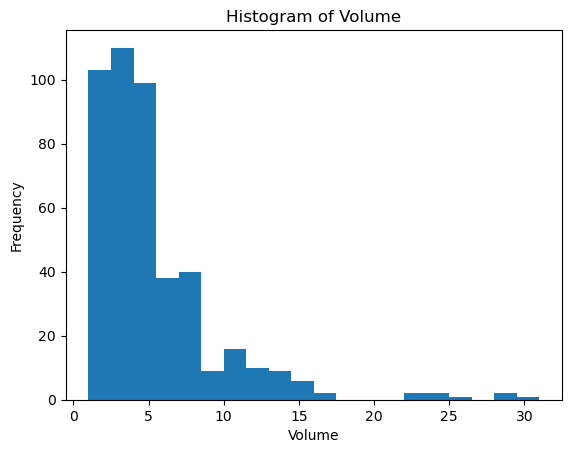

Column: Volume
Skewness: 2.73
Inference: Right skewed distribution


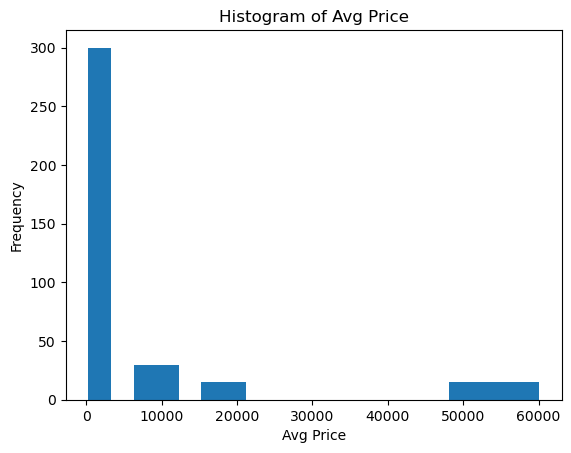

Column: Avg Price
Skewness: 1.91
Inference: Right skewed distribution


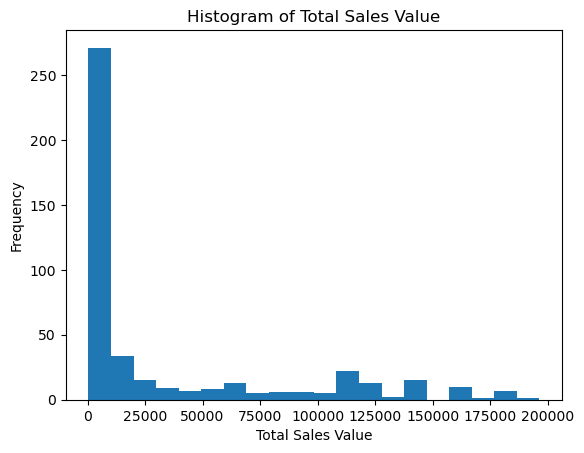

Column: Total Sales Value
Skewness: 1.53
Inference: Right skewed distribution


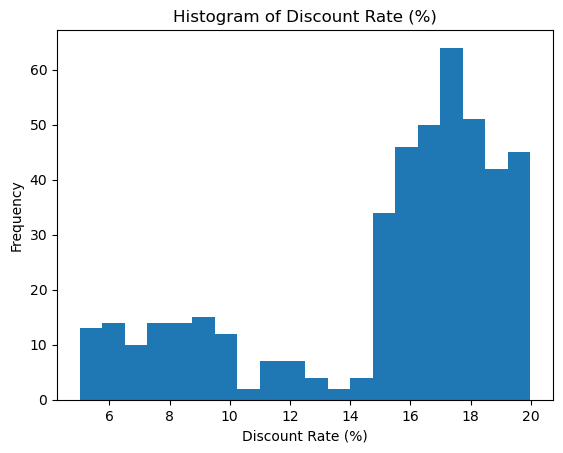

Column: Discount Rate (%)
Skewness: -1.06
Inference: Left skewed distribution


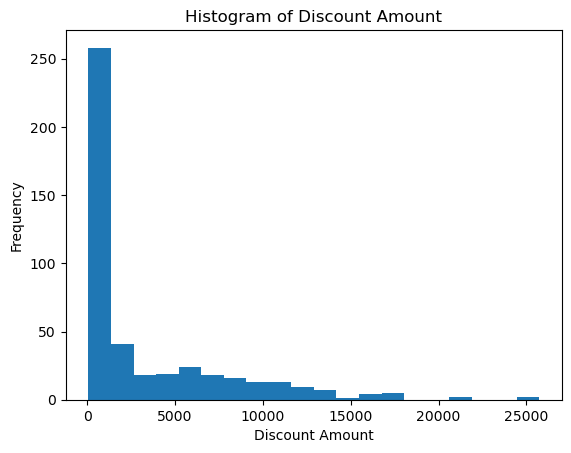

Column: Discount Amount
Skewness: 1.91
Inference: Right skewed distribution


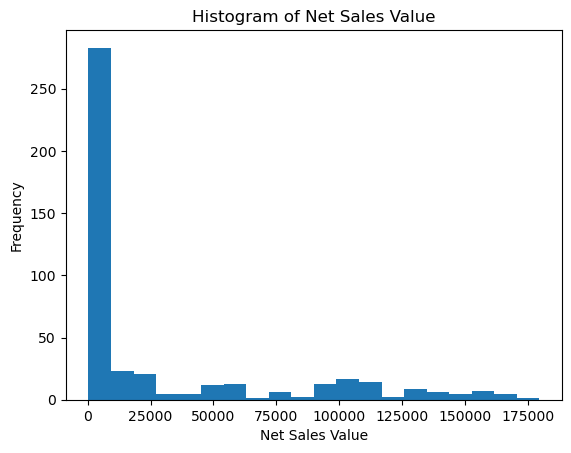

Column: Net Sales Value
Skewness: 1.54
Inference: Right skewed distribution


'\nHistograms show that several numerical variables are not normally distributed.\nSome columns display right-skewness, indicating concentration of lower values with few high extremes.\nA few variables appear approximately symmetric, suggesting balanced distributions.\nLong tails in histograms confirm potential outliers in certain features.\n'

In [32]:
# -------------------------------
# HISTOGRAMS
# -------------------------------
print("\n===== HISTOGRAM ANALYSIS =====")

for column in numeric_columns.columns:
    plt.figure()
    plt.hist(numeric_columns[column].dropna(), bins=20)
    plt.title(f'Histogram of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.show()

    skewness = numeric_columns[column].skew()
    print(f"Column: {column}")
    print(f"Skewness: {skewness:.2f}")

    if skewness > 0.5:
        print("Inference: Right skewed distribution")
    elif skewness < -0.5:
        print("Inference: Left skewed distribution")
    else:
        print("Inference: Approximately normal")

"""
Histograms show that several numerical variables are not normally distributed.
Some columns display right-skewness, indicating concentration of lower values with few high extremes.
A few variables appear approximately symmetric, suggesting balanced distributions.
Long tails in histograms confirm potential outliers in certain features.
"""
    


===== BOXPLOT ANALYSIS =====


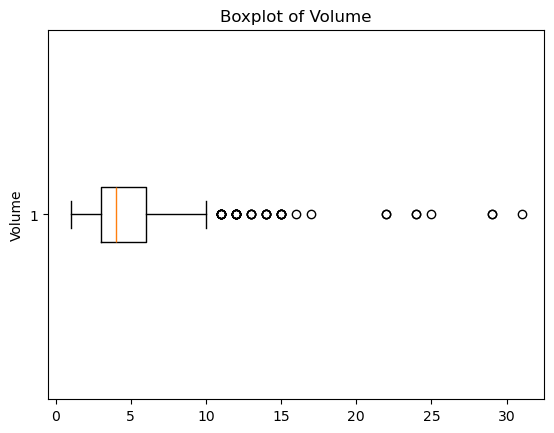


Column: Volume
Outliers detected: 44
Inference: Extreme values present


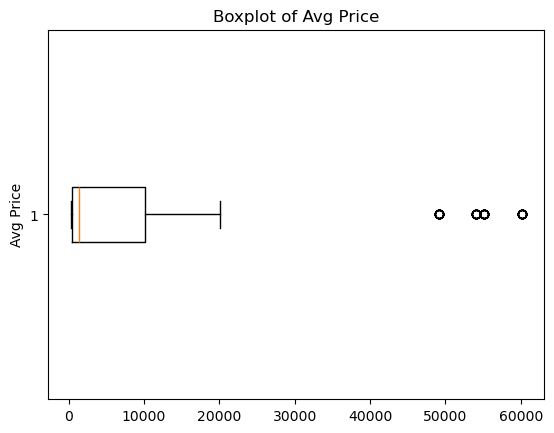


Column: Avg Price
Outliers detected: 60
Inference: Extreme values present


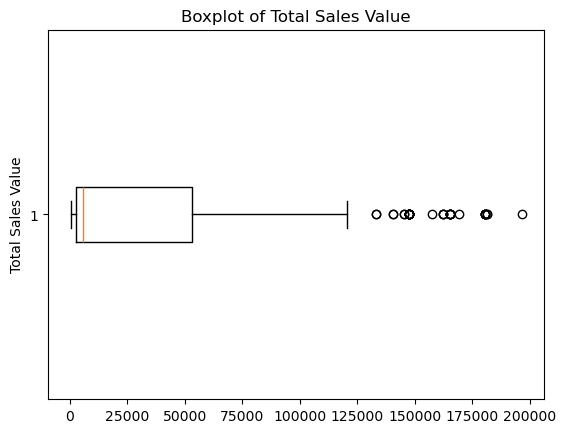


Column: Total Sales Value
Outliers detected: 36
Inference: Extreme values present


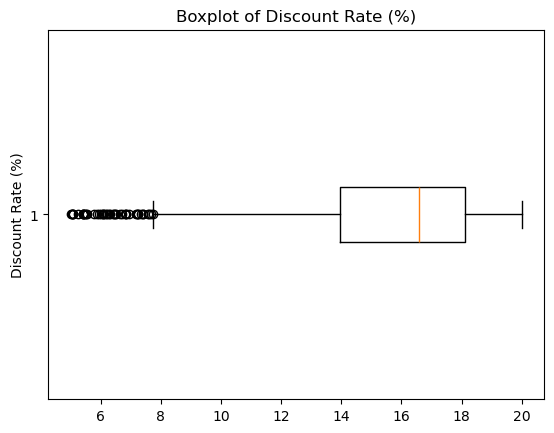


Column: Discount Rate (%)
Outliers detected: 45
Inference: Extreme values present


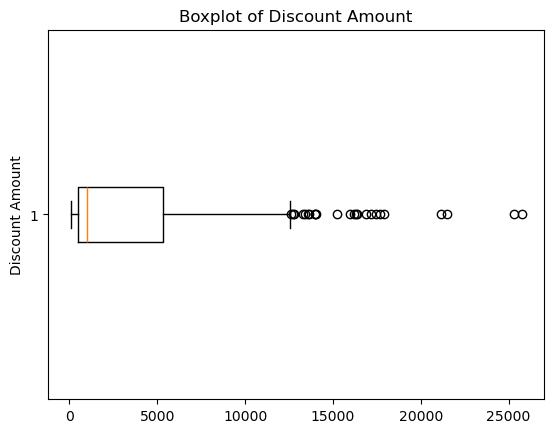


Column: Discount Amount
Outliers detected: 24
Inference: Extreme values present


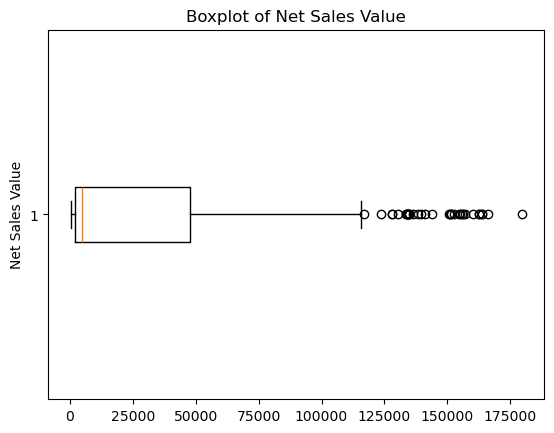


Column: Net Sales Value
Outliers detected: 35
Inference: Extreme values present


'\nBoxplots highlight outliers beyond the whiskers, confirming extreme values.\nWide interquartile ranges in some variables indicate high dispersion.\nNarrow boxplots suggest low variability and consistent data.\nCertain columns show multiple outliers, which may require preprocessing.\n'

In [33]:
# -------------------------------
# BOXPLOTS
# -------------------------------
print("\n===== BOXPLOT ANALYSIS =====")

for column in numeric_columns.columns:
    plt.figure()
    plt.boxplot(numeric_columns[column].dropna(), vert= False)
    plt.title(f'Boxplot of {column}')
    plt.ylabel(column)
    plt.show()

    q1 = numeric_columns[column].quantile(0.25)
    q3 = numeric_columns[column].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = numeric_columns[
        (numeric_columns[column] < lower) |
        (numeric_columns[column] > upper)
    ][column]

    print(f"\nColumn: {column}")
    print(f"Outliers detected: {len(outliers)}")

    if len(outliers) > 0:
        print("Inference: Extreme values present")
    else:
        print("Inference: No significant outliers")

"""
Boxplots highlight outliers beyond the whiskers, confirming extreme values.
Wide interquartile ranges in some variables indicate high dispersion.
Narrow boxplots suggest low variability and consistent data.
Certain columns show multiple outliers, which may require preprocessing.
"""


===== CATEGORICAL ANALYSIS =====


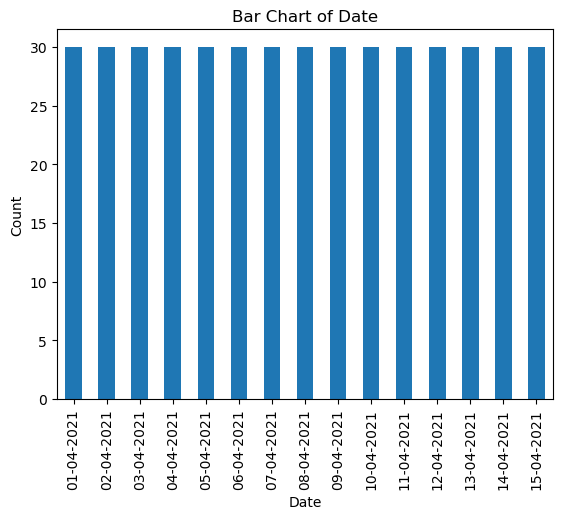


Column: Date
Date
01-04-2021    30
02-04-2021    30
03-04-2021    30
04-04-2021    30
05-04-2021    30
06-04-2021    30
07-04-2021    30
08-04-2021    30
09-04-2021    30
10-04-2021    30
11-04-2021    30
12-04-2021    30
13-04-2021    30
14-04-2021    30
15-04-2021    30
Name: count, dtype: int64
Insight:
Check dominant category and imbalance in distribution


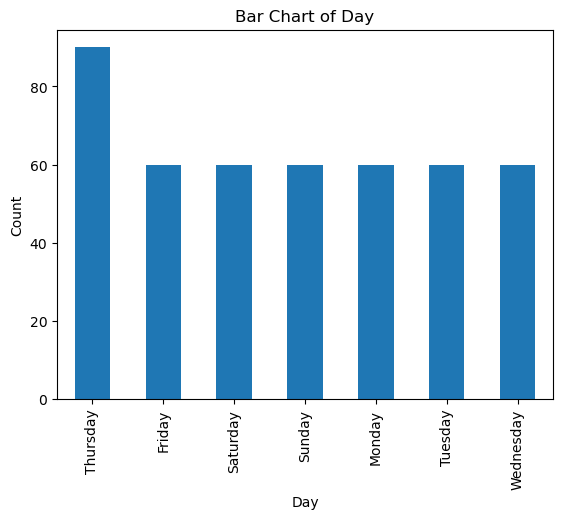


Column: Day
Day
Thursday     90
Friday       60
Saturday     60
Sunday       60
Monday       60
Tuesday      60
Wednesday    60
Name: count, dtype: int64
Insight:
Check dominant category and imbalance in distribution


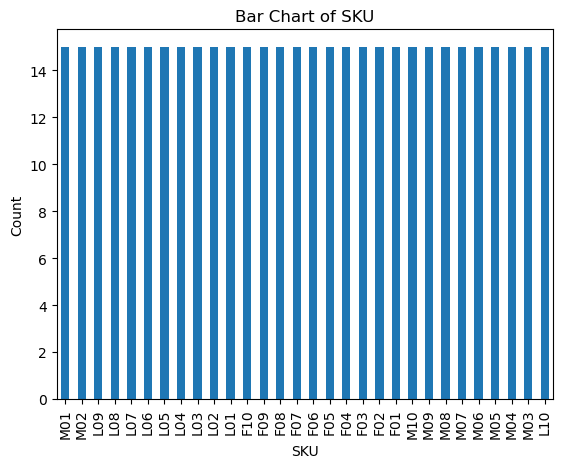


Column: SKU
SKU
M01    15
M02    15
L09    15
L08    15
L07    15
L06    15
L05    15
L04    15
L03    15
L02    15
L01    15
F10    15
F09    15
F08    15
F07    15
F06    15
F05    15
F04    15
F03    15
F02    15
F01    15
M10    15
M09    15
M08    15
M07    15
M06    15
M05    15
M04    15
M03    15
L10    15
Name: count, dtype: int64
Insight:
Check dominant category and imbalance in distribution


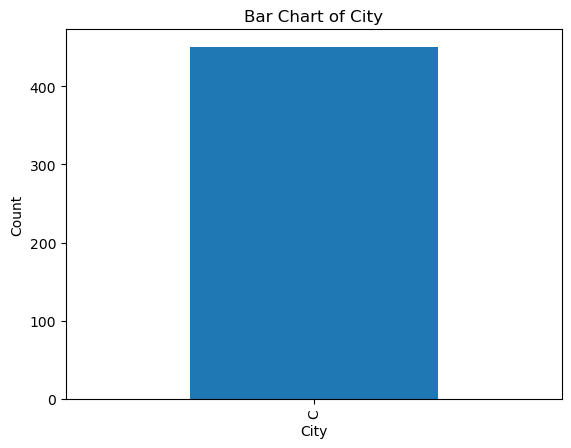


Column: City
City
C    450
Name: count, dtype: int64
Insight:
Check dominant category and imbalance in distribution


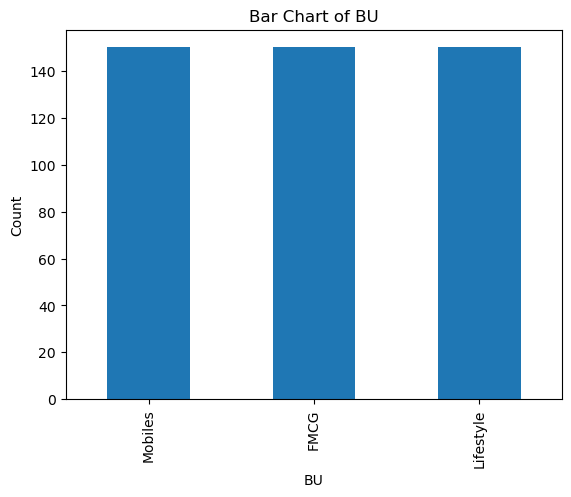


Column: BU
BU
Mobiles      150
FMCG         150
Lifestyle    150
Name: count, dtype: int64
Insight:
Check dominant category and imbalance in distribution


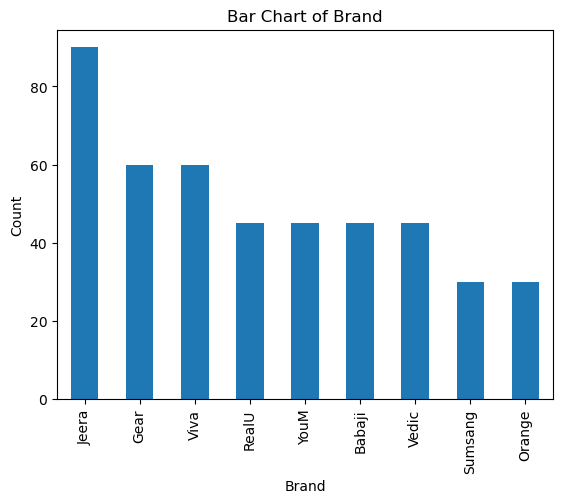


Column: Brand
Brand
Jeera      90
Gear       60
Viva       60
RealU      45
YouM       45
Babaji     45
Vedic      45
Sumsang    30
Orange     30
Name: count, dtype: int64
Insight:
Check dominant category and imbalance in distribution


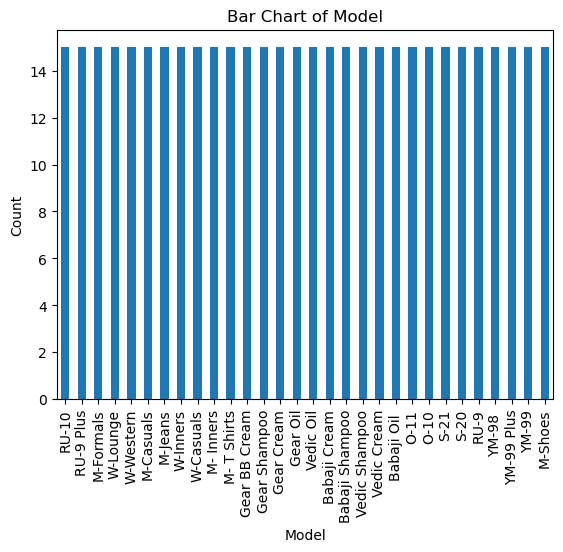


Column: Model
Model
RU-10             15
RU-9 Plus         15
M-Formals         15
W-Lounge          15
W-Western         15
M-Casuals         15
M-Jeans           15
W-Inners          15
W-Casuals         15
M- Inners         15
M- T Shirts       15
Gear BB Cream     15
Gear Shampoo      15
Gear Cream        15
Gear Oil          15
Vedic Oil         15
Babaji Cream      15
Babaji Shampoo    15
Vedic Shampoo     15
Vedic Cream       15
Babaji Oil        15
O-11              15
O-10              15
S-21              15
S-20              15
RU-9              15
YM-98             15
YM-99 Plus        15
YM-99             15
M-Shoes           15
Name: count, dtype: int64
Insight:
Check dominant category and imbalance in distribution


'\nBar charts reveal dominant categories in categorical variables.\nSome columns show class imbalance, where one category significantly outweighs others.\nUneven distribution suggests potential bias in data representation.\nCategories with very low frequency may need grouping or removal.\n'

In [34]:
# -------------------------------
# BAR CHART - CATEGORICAL
# -------------------------------
print("\n===== CATEGORICAL ANALYSIS =====")

categorical_columns = df.select_dtypes(include=['object', 'category'])

for column in categorical_columns.columns:
    counts = df[column].value_counts()

    plt.figure()
    counts.plot(kind='bar')
    plt.title(f'Bar Chart of {column}')
    plt.xlabel(column)
    plt.ylabel('Count')
    plt.show()

    print(f"\nColumn: {column}")
    print(counts)

    print("Insight:")
    print("Check dominant category and imbalance in distribution")

"""
Bar charts reveal dominant categories in categorical variables.
Some columns show class imbalance, where one category significantly outweighs others.
Uneven distribution suggests potential bias in data representation.
Categories with very low frequency may need grouping or removal.
"""